In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
#1.	Загрузка данных, вывод информации (.info(), .describe()).
df = pd.read_csv('avocado_ripeness_dataset.csv')
df.head()

,firmness,hue,saturation,brightness,color_category,sound_db,weight_g,size_cm3,ripeness
0,14.5,19,40,26,black,34,175,261,ripe
1,71.7,53,69,75,green,69,206,185,pre-conditioned
2,88.5,60,94,46,dark green,79,220,143,hard
3,93.8,105,87,41,dark green,75,299,140,hard
4,42.5,303,58,32,purple,63,200,227,breaking


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firmness        250 non-null    float64
 1   hue             250 non-null    int64  
 2   saturation      250 non-null    int64  
 3   brightness      250 non-null    int64  
 4   color_category  250 non-null    object 
 5   sound_db        250 non-null    int64  
 6   weight_g        250 non-null    int64  
 7   size_cm3        250 non-null    int64  
 8   ripeness        250 non-null    object 
dtypes: float64(1), int64(6), object(2)
memory usage: 17.7+ KB


In [58]:
df.describe()

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3
count,250.000000,250.00000,250.000000,250.00000,250.000000,250.000000,250.000000
mean,50.618400,125.94400,64.356000,45.07200,58.016000,220.188000,208.644000
std,27.277678,117.13767,17.377144,19.11629,13.838126,34.405225,55.940564
min,10.300000,1.00000,30.000000,10.00000,30.000000,152.000000,100.000000
25%,25.750000,25.25000,51.250000,31.00000,47.250000,193.250000,155.250000
50%,48.950000,77.00000,65.000000,46.00000,60.000000,220.000000,218.000000
75%,74.050000,278.75000,76.750000,58.00000,68.000000,245.000000,260.500000
max,98.800000,329.00000,99.000000,78.00000,79.000000,299.000000,299.000000


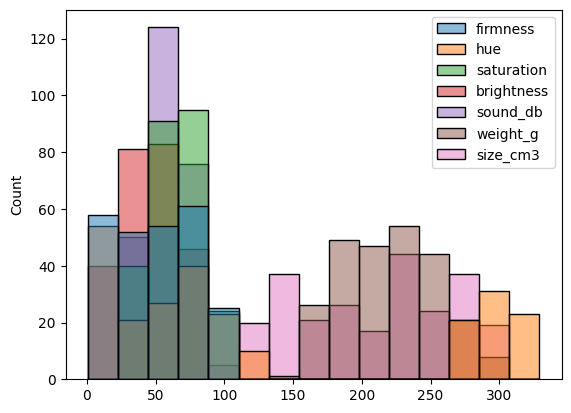

In [59]:
#2.	Анализ распределения каждого признака (гистограммы, boxplots).
sns.histplot(data=df)
plt.show()

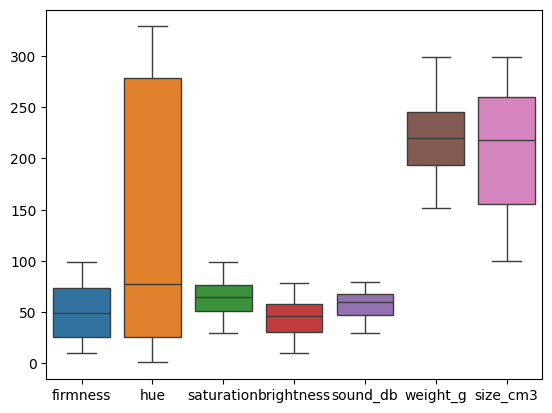

In [60]:
sns.boxplot(data=df)
plt.show()

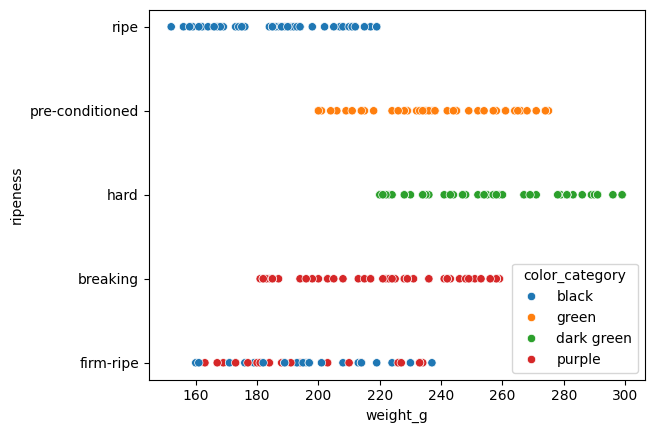

In [61]:
#3.	Анализ зависимости признаков от ripeness: o	firmness, weight_g, size_cm3 vs ripeness o	hue, saturation, brightness vs color_category vs ripeness
plt.figure()
sns.scatterplot(x='weight_g', y='ripeness', hue='color_category', data=df)
plt.show()

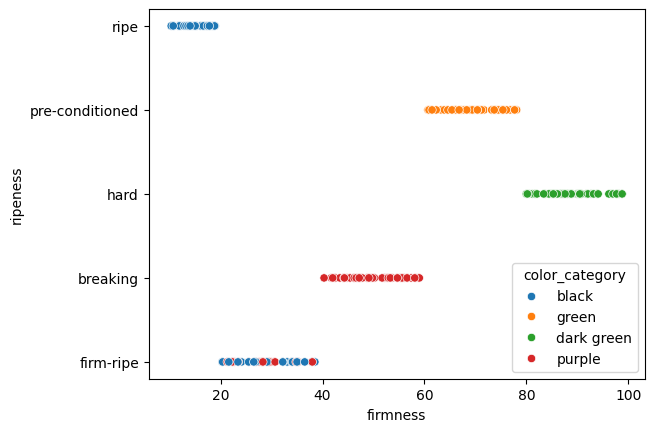

In [62]:
plt.figure()
sns.scatterplot(x='firmness', y='ripeness', hue='color_category', data=df)
plt.show()

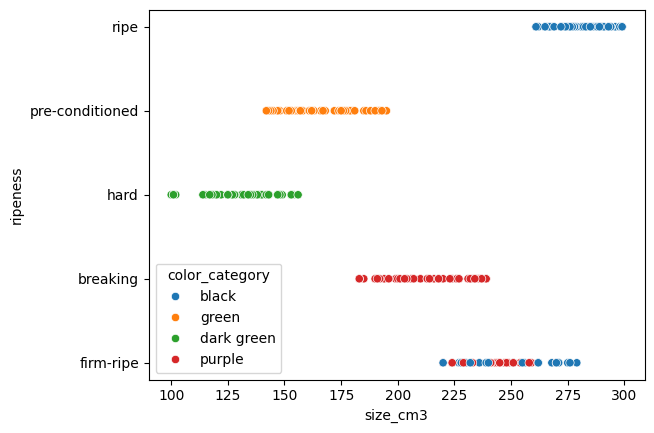

In [63]:
plt.figure()
sns.scatterplot(x='size_cm3', y='ripeness', hue='color_category', data=df)
plt.show()

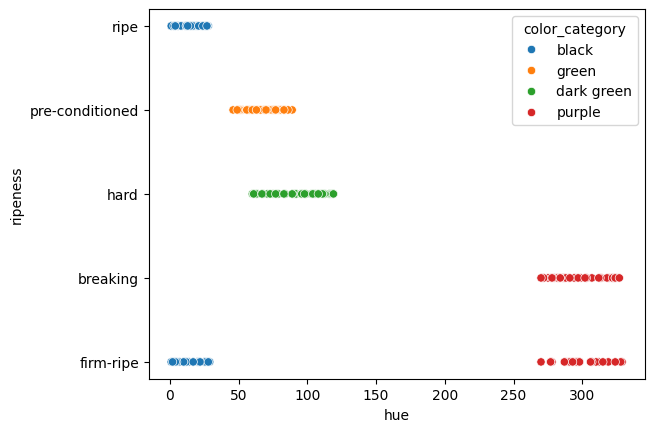

In [64]:
#o	hue, saturation, brightness vs color_category vs ripeness
plt.figure()
sns.scatterplot(x='hue', y='ripeness', hue='color_category', data=df)
plt.show()

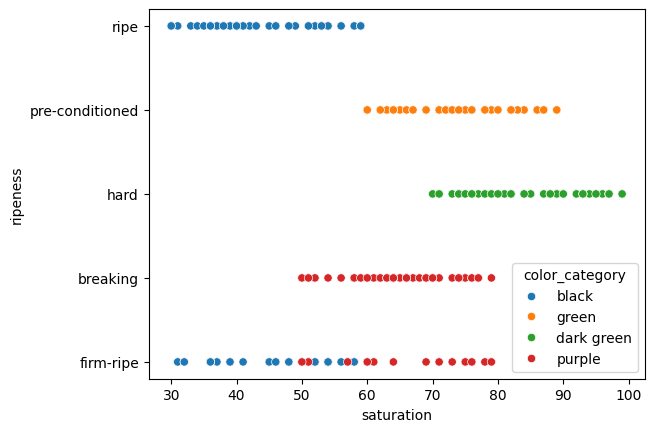

In [65]:
plt.figure()
sns.scatterplot(x='saturation', y='ripeness', hue='color_category', data=df)
plt.show()

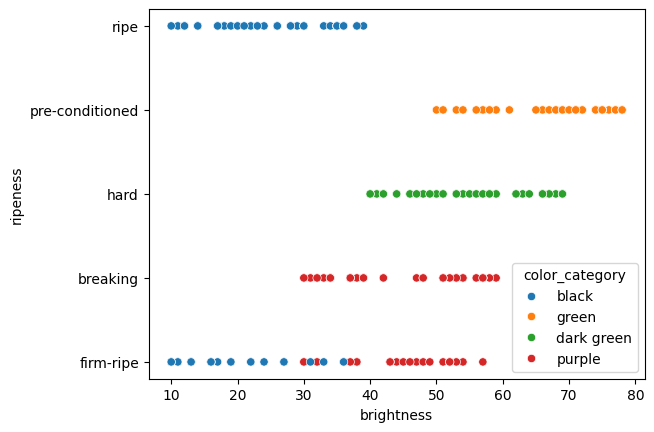

In [66]:
plt.figure()
sns.scatterplot(x='brightness', y='ripeness', hue='color_category', data=df)
plt.show()

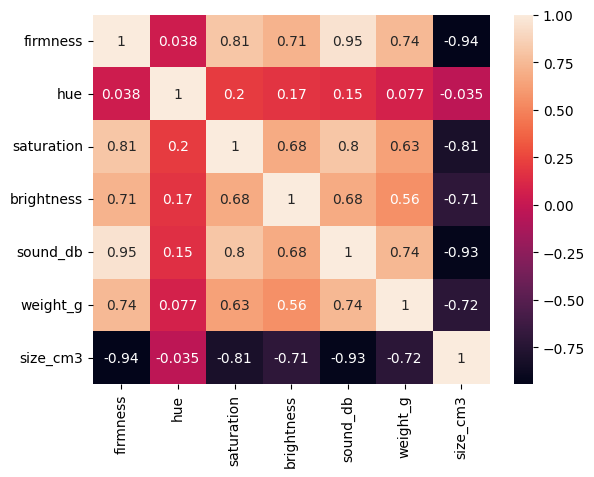

In [67]:
#4.	Анализ корреляций между числовыми признаками (heatmap, pairplot).
sns.heatmap(data=df.select_dtypes(exclude=('object')).corr(), annot=True)
plt.show()

In [68]:
#5.	Проверка и обработка пропусков, выбросов.
df.isnull().sum()

,0
firmness,0
hue,0
saturation,0
brightness,0
color_category,0
sound_db,0
weight_g,0
size_cm3,0
ripeness,0


In [69]:
#6.	Кодирование категориальных признаков (color_category) — OneHot или Label Encoding.
df = pd.get_dummies(df, columns=['color_category'], drop_first=True, dtype=int)

In [70]:
#7.	Масштабирование числовых признаков (MinMaxScaler, StandardScaler).
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [71]:
scaled_data = scaler.fit_transform(df.drop(columns='ripeness'))

In [72]:
#8.	Формирование X и y (разделение признаков и целевой переменной).
x = scaled_data
y = df['ripeness']

In [73]:
#9.	Разделение на обучающую и тестовую выборки (например, 80/20).
from sklearn.model_selection import train_test_split

In [74]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
#10.	Обучение нескольких моделей классификации:o	Logistic Regression (базовая модель)o	Random Forest Classifier (основная модель)o	(по желанию: XGBoost, LightGBM)
log_model = LogisticRegression()
log_model.fit(x_train, y_train)

LogisticRegression()

In [77]:
y_pred = log_model.predict(x_test)

In [78]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred, y_test)

1.0

In [79]:
import joblib

joblib.dump(log_model, 'avocado_model.pkl')
joblib.dump(scaler, '../models/avocado_scaler.pkl')

['avocado_scaler.pkl']

In [80]:
df.columns

Index(['firmness', 'hue', 'saturation', 'brightness', 'sound_db', 'weight_g',
       'size_cm3', 'ripeness', 'color_category_dark green',
       'color_category_green', 'color_category_purple'],
      dtype='object')

In [81]:
df

,firmness,hue,saturation,brightness,sound_db,weight_g,size_cm3,ripeness,color_category_dark green,color_category_green,color_category_purple
0,14.5,19,40,26,34,175,261,ripe,0,0,0
1,71.7,53,69,75,69,206,185,pre-conditioned,0,1,0
2,88.5,60,94,46,79,220,143,hard,1,0,0
3,93.8,105,87,41,75,299,140,hard,1,0,0
4,42.5,303,58,32,63,200,227,breaking,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
245,94.1,83,80,58,72,254,134,hard,1,0,0
246,21.6,17,36,19,47,182,240,firm-ripe,0,0,0
247,14.0,4,40,17,37,188,274,ripe,0,0,0
248,61.5,63,87,75,65,261,162,pre-conditioned,0,1,0
